**Principal Component Analysis (PCA) on Human Activity Recognition (Smartphone Sensors)**

In [29]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [30]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\Yug\Downloads\test.csv\test.csv")
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


## Dataset Description / Synopsis

The **Human Activity Recognition (HAR)** dataset consists of sensor data collected from smartphones to identify and classify human physical activities using machine learning techniques.

### Data Collection
The data was recorded using a smartphone placed on the waist of the subjects. The smartphone is equipped with two primary sensors:
- **Accelerometer**, which measures linear acceleration
- **Gyroscope**, which measures angular velocity

Sensor signals were captured while subjects performed various daily activities under controlled conditions.

### Activities (Target Variable)
The dataset includes six activity classes:
1. Walking  
2. Walking Upstairs  
3. Walking Downstairs  
4. Sitting  
5. Standing  
6. Laying  

The **`Activity`** column represents the target variable for classification.

### Subjects
Data was collected from **30 different subjects**, each performing all six activities.  
The **`subject`** column identifies the participant and is used only for reference, not for prediction.

### Features
- Total number of features: **561**
- All features are **numerical**
- Features are derived from raw accelerometer and gyroscope signals recorded along the **X, Y, and Z axes**
- Both **time-domain** and **frequency-domain** features are included

Extracted features include statistical measures such as:
- Mean and standard deviation
- Signal energy and entropy
- Correlation and angle-based features

These features are carefully engineered to capture motion characteristics associated with different activities.

### Dataset Characteristics
- No missing values
- High dimensionality with significant feature correlation
- Suitable for supervised classification and dimensionality reduction techniques such as PCA

### Motivation for PCA
Due to the large number of correlated sensor features, Principal Component Analysis (PCA) is applied to reduce dimensionality, remove redundancy, and analyze the impact of feature reduction on classification performance.


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 12.7 MB


In [32]:
df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720,12.986427
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467,6.950984
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228,2.000000
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485,9.000000
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671,12.000000
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373,18.000000
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113,24.000000


In [33]:
df.isnull().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

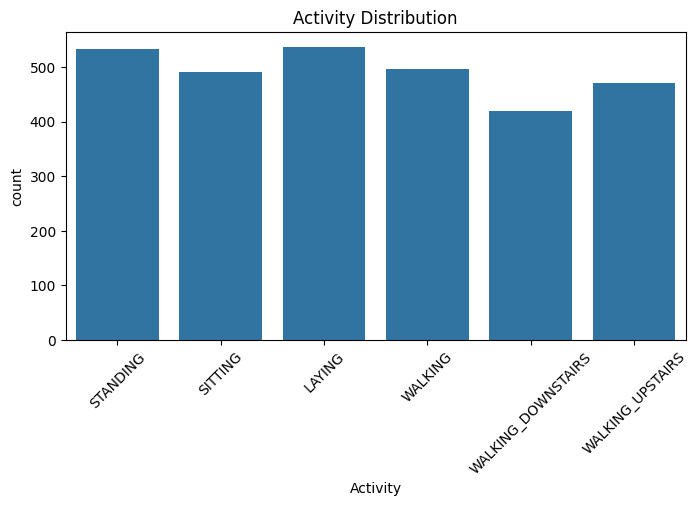

In [34]:
# Target Variable Distribution
plt.figure(figsize=(8,4))
sns.countplot(x='Activity', data=df)
plt.xticks(rotation=45)
plt.title("Activity Distribution")
plt.show()

In [35]:
# Feature–Target Separation
X = df.drop(columns=['Activity', 'subject'])
y = df['Activity']

# Converting categorical data to numerical
le = LabelEncoder()
y = le.fit_transform(y)


In [36]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Accuracy before PCA
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
baseline_accuracy = metrics.accuracy_score(y_test, y_pred)
print("Baseline Accuracy (Without PCA):", baseline_accuracy)


Baseline Accuracy (Without PCA): 0.9813559322033898


In [39]:
# PCA with 2 components
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2 = pca_2.transform(X_test_scaled)
clf_pca2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca2.fit(X_train_pca2, y_train)
y_pred_pca2 = clf_pca2.predict(X_test_pca2)
pca2_accuracy = metrics.accuracy_score(y_test, y_pred_pca2)
print("Accuracy with PCA (2 components):", pca2_accuracy)


Accuracy with PCA (2 components): 0.5644067796610169


In [40]:
# PCA with 3 components
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)
clf_pca3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca3.fit(X_train_pca3, y_train)
y_pred_pca3 = clf_pca3.predict(X_test_pca3)
pca3_accuracy = metrics.accuracy_score(y_test, y_pred_pca3)
print("Accuracy with PCA (3 components):", pca3_accuracy)

Accuracy with PCA (3 components): 0.6322033898305085


In [41]:
# PCA with 10 components
pca_10 = PCA(n_components=10)
X_train_pca10 = pca_10.fit_transform(X_train_scaled)
X_test_pca10 = pca_10.transform(X_test_scaled)
clf_pca10 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca10.fit(X_train_pca10, y_train)
y_pred_pca10 = clf_pca10.predict(X_test_pca10)
pca10_accuracy = metrics.accuracy_score(y_test, y_pred_pca10)
print("Accuracy with PCA (10 components):", pca10_accuracy)

Accuracy with PCA (10 components): 0.8898305084745762


In [43]:
# PCA with 100 components
pca_100 = PCA(n_components=100)
X_train_pca100 = pca_100.fit_transform(X_train_scaled)
X_test_pca100 = pca_100.transform(X_test_scaled)
clf_pca100 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca100.fit(X_train_pca100, y_train)
y_pred_pca100 = clf_pca100.predict(X_test_pca100)
pca100_accuracy = metrics.accuracy_score(y_test, y_pred_pca100)
print("Accuracy with PCA (100 components):", pca100_accuracy)

Accuracy with PCA (100 components): 0.9576271186440678


In [44]:
# Accuracy comparison
print("Model Accuracy Comparison\n")
print("Baseline (No PCA):", baseline_accuracy)
print("PCA with 2 components:", pca2_accuracy)
print("PCA with 3 components:", pca3_accuracy)
print("PCA with 10 components:", pca10_accuracy)
print("PCA with 100 components:", pca100_accuracy)

Model Accuracy Comparison

Baseline (No PCA): 0.9813559322033898
PCA with 2 components: 0.5644067796610169
PCA with 3 components: 0.6322033898305085
PCA with 10 components: 0.8898305084745762
PCA with 100 components: 0.9576271186440678


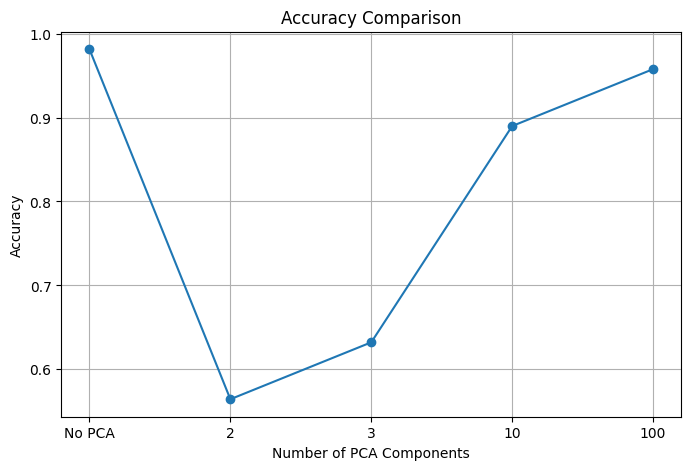

In [55]:
# Accuracy comparison (Graph)
results = pd.DataFrame({
    "PCA Components": ["No PCA", "2", "3", "10", "100"],
    "Accuracy": [
        baseline_accuracy,
        pca2_accuracy,
        pca3_accuracy,
        pca10_accuracy,
        pca100_accuracy
    ]
})

plt.figure(figsize=(8,5))
plt.plot(results["PCA Components"], results["Accuracy"], marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(True)
plt.show()


## Observations / Outcomes

- The baseline Random Forest classifier without PCA achieved the highest accuracy (≈98.14%), serving as the reference model.
- Applying PCA with very few components (2 and 3) resulted in substantial accuracy loss due to excessive dimensionality reduction.
- As the number of PCA components increased, classification accuracy improved because more variance and discriminative information were retained.
- PCA with 10 components showed significant improvement compared to lower component counts, but still underperformed the baseline.
- PCA with 100 components achieved accuracy close to the baseline, indicating effective variance retention with reduced dimensionality.
- The experiment highlights the trade-off between dimensionality reduction and classification performance in high-dimensional sensor data.
